# Chi-Square Goodness-of-Fit Test

The **chi-square goodness-of-fit test** checks whether observed frequency counts match expected frequencies from a specified distribution. It is the standard test for discrete data and can also be applied to binned continuous data.

| Property | Value |
|---|---|
| **H₀** | Data follows the specified distribution |
| **H₁** | Data does not follow the distribution |
| **Test statistic** | χ² = Σ (Oᵢ − Eᵢ)² / Eᵢ |
| **df** | (k − 1 − p) where k=bins, p=estimated parameters |
| **Assumption** | Eᵢ ≥ 5 for all bins (merge bins if needed) |
| **For discrete** | Use natural categories (e.g. die faces, count values) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

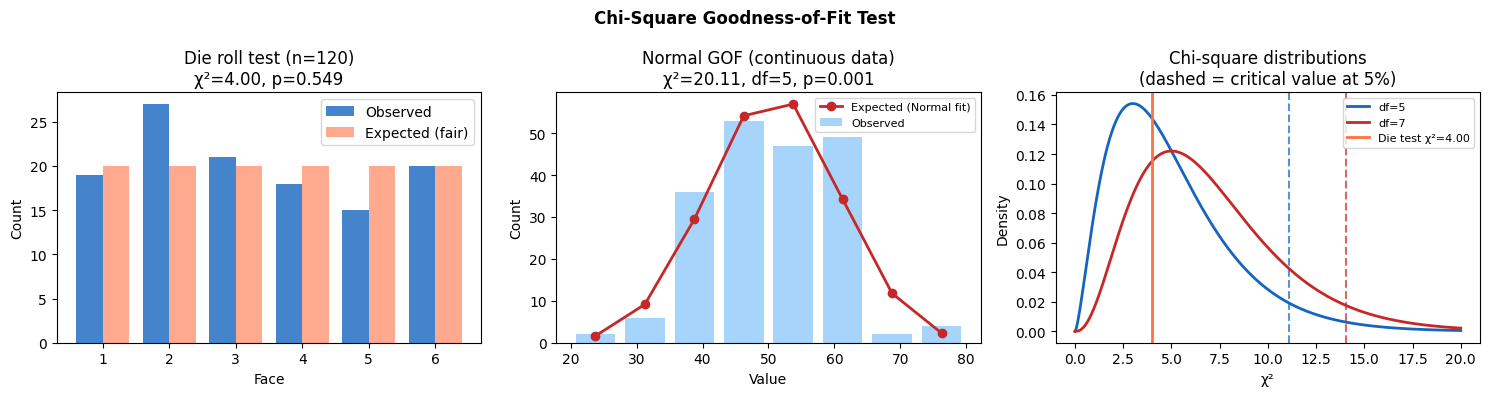

Die test: χ²=4.0000, df=5, p=0.5494
Normal GOF: χ²=20.1060, df=5, p=0.0012


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Chi-Square Goodness-of-Fit Test', fontsize=12, fontweight='bold')

# Panel 1: Fair die test
n_rolls = 120
# Fair die
observed_fair = np.random.multinomial(n_rolls, [1/6]*6)
expected = np.full(6, n_rolls/6)
chi2_fair, p_fair = stats.chisquare(observed_fair)

faces = np.arange(1, 7)
axes[0].bar(faces - 0.2, observed_fair, 0.4, color='#1565C0', alpha=0.8, label='Observed')
axes[0].bar(faces + 0.2, expected, 0.4, color='#FF7043', alpha=0.6, label='Expected (fair)')
axes[0].set_title(f'Die roll test (n={n_rolls})\nχ²={chi2_fair:.2f}, p={p_fair:.3f}')
axes[0].set_xlabel('Face'); axes[0].set_ylabel('Count')
axes[0].set_xticks(faces); axes[0].legend()

# Panel 2: Normal fit to binned continuous data
data = np.random.normal(50, 10, 200)
bins = np.linspace(20, 80, 9)
obs_counts, _ = np.histogram(data, bins=bins)
mu_hat, sigma_hat = data.mean(), data.std(ddof=1)
exp_probs = np.diff(stats.norm.cdf(bins, mu_hat, sigma_hat))
exp_counts = exp_probs * len(data)
chi2_norm = ((obs_counts - exp_counts)**2 / exp_counts).sum()
df_norm = len(obs_counts) - 1 - 2  # subtract 2 estimated params
p_norm = stats.chi2.sf(chi2_norm, df_norm)

bin_centers = (bins[:-1] + bins[1:]) / 2
axes[1].bar(bin_centers, obs_counts, width=np.diff(bins)[0]*0.8,
            color='#90CAF9', alpha=0.8, label='Observed')
axes[1].plot(bin_centers, exp_counts, 'o-', color='#C62828', lw=2, ms=6, label='Expected (Normal fit)')
axes[1].set_title(f'Normal GOF (continuous data)\nχ²={chi2_norm:.2f}, df={df_norm}, p={p_norm:.3f}')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

# Panel 3: chi-square distribution
chi2_range = np.linspace(0, 20, 400)
for df_plot, color, label in [(5, '#1565C0', 'df=5'), (7, '#C62828', 'df=7')]:
    axes[2].plot(chi2_range, stats.chi2.pdf(chi2_range, df_plot), color=color, lw=2, label=label)
    crit = stats.chi2.ppf(0.95, df_plot)
    axes[2].axvline(crit, color=color, lw=1.5, ls='--', alpha=0.7)
axes[2].axvline(chi2_fair, color='#FF7043', lw=2, label=f'Die test χ²={chi2_fair:.2f}')
axes[2].set_title('Chi-square distributions\n(dashed = critical value at 5%)')
axes[2].set_xlabel('χ²'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Die test: χ²={chi2_fair:.4f}, df=5, p={p_fair:.4f}')
print(f'Normal GOF: χ²={chi2_norm:.4f}, df={df_norm}, p={p_norm:.4f}')

## Key Takeaways

| | |
|---|---|
| **df = k−1−p** | Subtract estimated parameters (2 for Normal: mean, SD) |
| **Merge small bins** | Combine bins until all E_i ≥ 5 |
| **Discrete data** | Use natural categories; no binning needed |
| **Binning choice** | Results depend on bin width — use equal-probability bins when possible |
| **vs Anderson-Darling** | AD is more powerful for continuous data; χ² GOF is needed for discrete |
| **Two-way extension** | Chi-square independence test is a 2D generalisation of GOF |